# UC San Diego: Neural Data Science
## Gen AI 

## Permissions

Place an `X` in the appropriate bracket below to specify if you would like your group's project to be made available to the public. (Note that student names will be included (but PIDs will be scraped from any groups who include their PIDs).

* [ X ] YES - make available
* [  ] NO - keep private

# Names

- Aidan Ho
- Ranya Tashkandy
- Nasrin Omar

# Overview

In this project, we compare self-reported cognitive-function measures from two college datasets collected before and after the widespread adoption of generative AI. Because the datasets used different survey instruments and scoring scales, composite cognitive-function scores were standardized using z-score normalization to facilitate comparison. We specifically examine whether students surveyed after the widespread adoption of generative AI exhibit lower standardized cognitive-function measures than students surveyed before its adoption. Using data visualizations and statistical analysis, we compare the distributions of standardized cognitive-function measures between pre-AI and post-AI cohorts. Our goal is not to determine whether AI directly causes cognitive changes, but rather to examine whether measurable differences exist between students surveyed before and after the widespread adoption of generative AI. 

<a id='research_question'></a>
# Research Question

How do self-reported cognitive-function scores differ between college student cohorts sampled before (2018–2019) and after (2023–2025) the widespread adoption of generative AI?

**Variables:**
- **Grouping variable:** AI era — Pre-AI (RU Mindful, 2018–2019) vs. Post-AI (UEF-1, 2024)
- **Primary Outcome** Variable: Standardized cognitive-function score (z-score) 

<a id='background'></a>

## Background & Prior Work

Artificial intelligence tools have revolutionized the way we learn and create in our world, allowing students to finish homework, create art, and answer difficult questions in a matter of seconds. For many students, tools like AI have already become normal, making information faster and easier to access than ever before. But is the reliance that all these students seem to have on AI as innocent as it seems?

Research has raised concerns about the overdependence on tools like AI, believing that some students rely on AI instead of thinking through problems on their own. This idea is known as “cognitive offloading,” where technology performs thinking tasks that people previously would have done on their own (Risko & Gilbert, 2016). Risko and Gilbert found that while offloading tasks to external tools can boost immediate performance, it simultaneously reduces memory encoding and independent recall over time. These effects may influence attention, learning habits, and independent problem-solving abilities, potentially contributing to reduced deep focus and increased reliance on immediate answers.
This topic is particularly important because millions of students now have AI embedded in their studying and learning routines. Georgiou (2025) conducted a controlled experiment where 40 students completed an argumentative writing task either with or without ChatGPT assistance, and found that students who used ChatGPT scored significantly lower on cognitive engagement, including less deep processing, less mental effort, weaker sustained attention, and less strategic thinking than students who worked independently. Similarly, Aruon, Shealy, and Gero (2025) used functional near-infrared spectroscopy to examine brain activity in undergraduate students completing design tasks with and without generative AI assistance. They found that students using AI exhibited lower activation in the prefrontal cortex, a brain region associated with executive functioning and higher-order reasoning, and that this reduction persisted even during later tasks when AI was no longer available.

While previous studies have examined the effects of AI-assisted task completion on cognitive engagement and executive functioning, there is limited population-level evidence comparing cognitive-function measures across student cohorts before and after the widespread adoption of generative AI.

References (include links):
- 1)https://ciddl.org/artificial-intelligence-and-executive-functioning-enhancing-attention-self-regulation-and-planning-in-the-classroom/
- 2)https://www.psypost.org/ai-tools-may-weaken-critical-thinking-skills-by-encouraging-cognitive-offloading-study-suggests/
- 3)https://pmc.ncbi.nlm.nih.gov/articles/PMC12036037/

# Hypothesis


We hypothesize that college students sampled after the widespread adoption of generative AI will report lower standardized cognitive-functioning scores than students sampled before its adoption. As generative AI becomes more integrated into students’ academic routines, greater reliance on these tools may be associated with lower self-reported cognitive functioning.


# Dataset(s)

*Fill in your dataset information here*

(Copy this information for each dataset)
- Dataset Name:
- Link to the dataset:
- Number of observations:

1-2 sentences describing each dataset. 

If you plan to use multiple datasets, add 1-2 sentences about how you plan to combine these datasets.

| Dataset | Source | Era | N |
|---|---|---|---|
| RU Mindful | [rdw.rowan.edu/datasets/2](https://rdw.rowan.edu/datasets/2/) | Pre-AI (2018–2019) | 534 |
| UEF-1 | [data.mendeley.com/datasets/gfrmzgmkbt/2](https://data.mendeley.com/datasets/gfrmzgmkbt/2) | Post-AI (2024) | 1,373 |

# Data Wrangling

* Explain steps taken to pull the data you need into Python.

In [9]:
pip install pandas numpy scipy matplotlib seaborn openpyxl requests


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [10]:
import pandas as pd
import numpy as np
import requests
import io

from scipy.stats import zscore, ttest_ind

import matplotlib.pyplot as plt
import seaborn as sns



In [11]:
# Pre-AI (Rowan dataset)
RU_URL = "https://rdw.rowan.edu/context/datasets/article/1002/type/native/viewcontent"

ru_raw = pd.read_excel(
    io.BytesIO(requests.get(RU_URL, timeout=60).content),
    engine="openpyxl"
)

# Post-AI dataset
uef_raw = pd.read_excel(
    "UEF_dataset.xlsx",
    engine="openpyxl"
)


In [12]:
print("Pre-AI shape:", ru_raw.shape)
print("Post-AI shape:", uef_raw.shape)


Pre-AI shape: (534, 16)
Post-AI shape: (1373, 42)


# Data Cleaned
To make the datasets easier to work with, column names were standardized by converting them to lowercase and removing spaces and special
characters.

In [13]:
def clean_cols(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(r"[\s\-/]+", "_", regex=True)
        .str.replace(r"[^\w]", "", regex=True)
    )
    return df

ru = clean_cols(ru_raw.copy())
uef = clean_cols(uef_raw.copy())


## Creating Cognitive-Function Measures
The datasets use different survey instruments.
To create comparable measures, composite cognitive-function scores were calculated for each dataset.

In [14]:
# PRE-AI: cognitive function score

ru["cognitiveabilities"] = pd.to_numeric(ru["cognitiveabilities"], errors="coerce")
ru["cognitivefunctioning"] = pd.to_numeric(ru["cognitivefunctioning"], errors="coerce")

ru["cog_score"] = ru[["cognitiveabilities", "cognitivefunctioning"]].mean(axis=1)

pre = ru["cog_score"].dropna()

# POST-AI: executive function score


subscales = [
    "monitorizacionconscieteresponsabilidades",
    "sistemaatencionalsupervisor",
    "regulaciondeliberadaemocion",
    "verificaciondelaconducta",
    "tomadedecisiones",
    "controlinhibitorio",
    "organizacionelemnetostareas"
]

# rename safely to avoid long names
uef_rename = {c: f"f{i}" for i, c in enumerate(subscales, 1)}
uef = uef.rename(columns=uef_rename)

subscales_clean = list(uef_rename.values())

for col in subscales_clean:
    uef[col] = pd.to_numeric(uef[col], errors="coerce")

uef["cog_score"] = uef[subscales_clean].mean(axis=1)

post = uef["cog_score"].dropna()


# combined

df = pd.concat([
    pd.DataFrame({"era": "pre_AI", "cog_score": pre}),
    pd.DataFrame({"era": "post_AI", "cog_score": post})
])




## Analyze and Integrate Datasets
Because the two datasets use different scoring scales, raw scores cannot be directly compared.
To place both datasets on a common scale, z-score normalization was applied.

In [15]:
pre_z = zscore(pre)
post_z = zscore(post)


In [16]:
df = pd.concat([
    pd.DataFrame({
        "era": "Pre-AI",
        "score": pre_z
}),
pd.DataFrame({
    "era": "Post-AI",
    "score": post_z
})
])
df.head()


,era,score
0,Pre-AI,1.521220
1,Pre-AI,-1.220249
2,Pre-AI,0.678218
3,Pre-AI,0.643950
4,Pre-AI,1.665147


In [17]:
df["era"].value_counts()


era
Post-AI    1373
Pre-AI      534
Name: count, dtype: int64

## Descriptive Statistics
The following table summarizes the distributions of standardized cognitive-function scores.

In [18]:
df.groupby("era")["score"].agg([
"count",
"mean",
"median",
"std",
"min",
"max"
])


,count,mean,median,std,min,max
era,,,,,,
Post-AI,1373,1.465850e-15,0.105085,1.000364,-3.153736,2.154989
Pre-AI,534,9.936392e-16,-0.072259,1.000938,-2.954228,2.323100


# Data Visualization 1: Distribution of Standardized Cognitive Function Scores

* This is a good place for some relevant visualizations related to any exploratory data anlayses (EDA) you did after the basic cleaning.

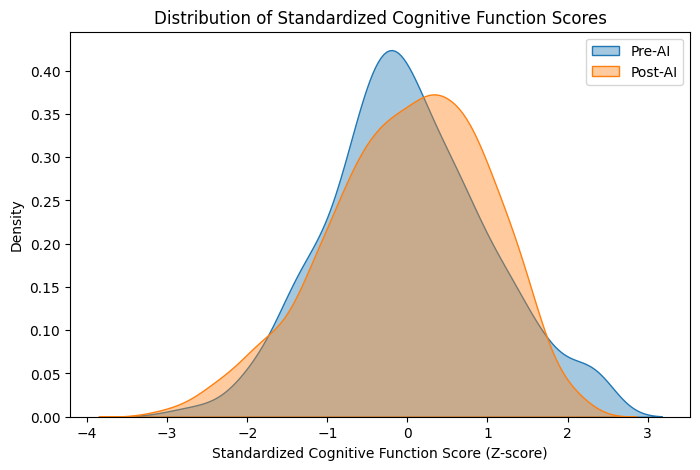

In [19]:
plt.figure(figsize=(8,5))
sns.kdeplot(
    pre_z,
    label="Pre-AI",
    fill=True,
    alpha=0.4
)
sns.kdeplot(
    post_z,
    label="Post-AI",
    fill=True,
    alpha=0.4
)
plt.title("Distribution of Standardized Cognitive Function Scores")
plt.xlabel("Standardized Cognitive Function Score (Z-score)")
plt.ylabel("Density")
plt.legend()
plt.show()


## Visualization 2: Boxplot Comparison

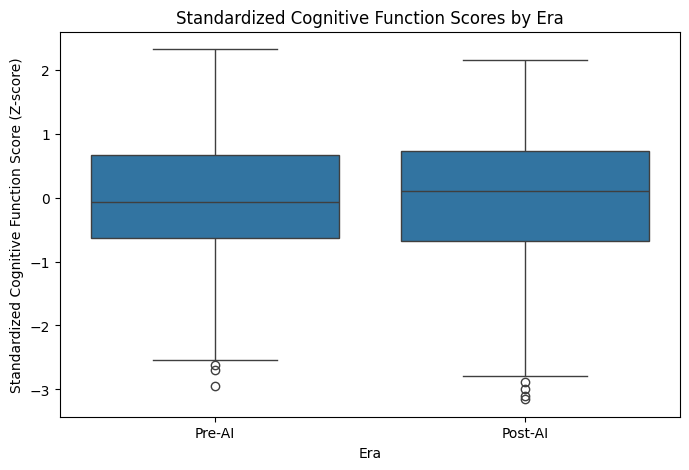

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="era",
    y="score"
)
plt.title("Standardized Cognitive Function Scores by Era")
plt.xlabel("Era")
plt.ylabel("Standardized Cognitive Function Score (Z-score)")
plt.show()


## Visualization 3: Violin Plot
A violin plot combines features of a boxplot and density plot. It allows us to examine both summary statistics and the underlying distribution of scores
within each cohort.

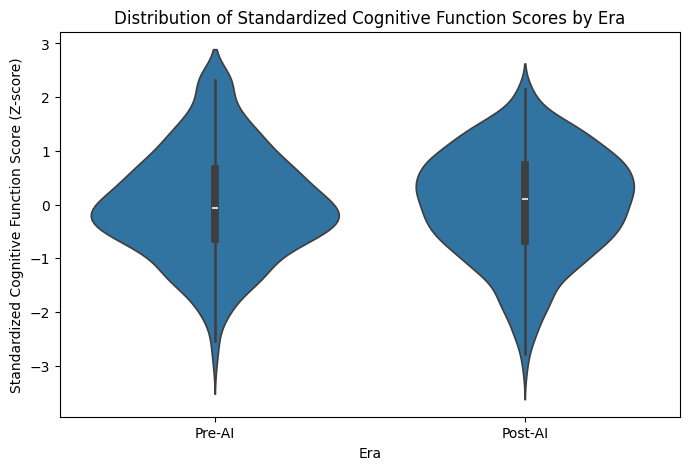

In [21]:
plt.figure(figsize=(8,5))
sns.violinplot(
    data=df,
    x="era",
    y="score",
    inner="box"
)
plt.title("Distribution of Standardized Cognitive Function Scores by Era")
plt.xlabel("Era")
plt.ylabel("Standardized Cognitive Function Score (Z-score)")
plt.show()


## Distribution of Cognitive Function Scores

This histogram shows that the Pre-AI and Post-AI cohorts have largely overlapping cognitive-function score distributions, indicating similar overall performance patterns.


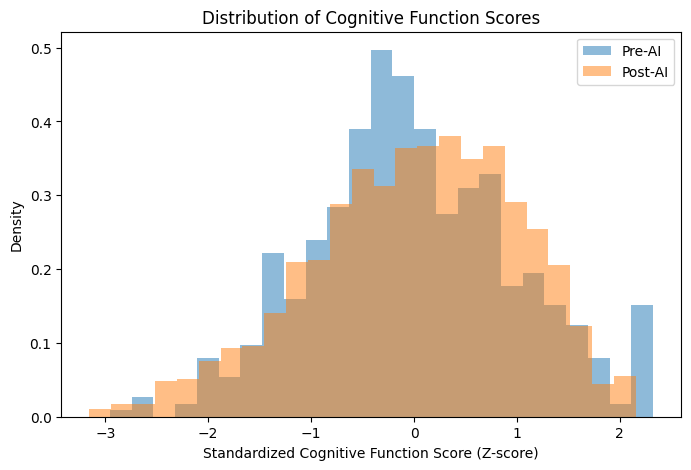

In [30]:
plt.figure(figsize=(8,5))

plt.hist(pre_z, bins=25, alpha=0.5, label="Pre-AI", density=True)
plt.hist(post_z, bins=25, alpha=0.5, label="Post-AI", density=True)

plt.xlabel("Standardized Cognitive Function Score (Z-score)")
plt.ylabel("Density")
plt.title("Distribution of Cognitive Function Scores")
plt.legend()

plt.show()


## Cumulative Distribution of Cognitive Function Scores

This plot compares the cumulative distributions of cognitive-function scores for the Pre-AI and Post-AI cohorts, showing that the two groups have broadly similar score patterns.



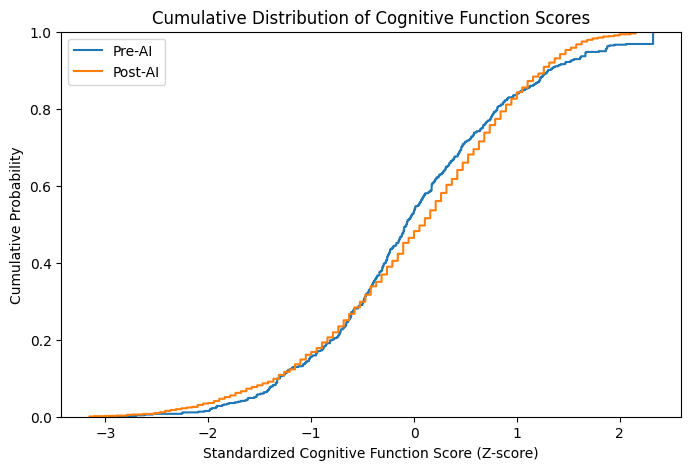

In [31]:

plt.figure(figsize=(8,5))

sns.ecdfplot(pre_z, label="Pre-AI")
sns.ecdfplot(post_z, label="Post-AI")

plt.xlabel("Standardized Cognitive Function Score (Z-score)")
plt.ylabel("Cumulative Probability")
plt.title("Cumulative Distribution of Cognitive Function Scores")
plt.legend()

plt.show() 



## Mean Cognitive Function Scores by Era

This bar chart compares the average standardized cognitive-function scores of the Pre-AI and Post-AI cohorts. The error bars represent 95% confidence intervals, showing the uncertainty around the estimated mean scores and helping assess whether meaningful differences exist between the groups.

Text(0.5, 1.0, 'Mean Cognitive Function Score by Era')

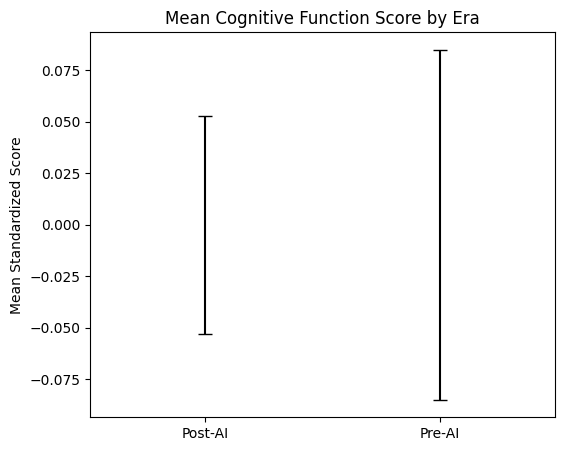

In [32]:
summary = df.groupby("era")["score"].agg(["mean","std","count"])

summary["se"] = summary["std"] / np.sqrt(summary["count"])
summary["ci"] = 1.96 * summary["se"]

plt.figure(figsize=(6,5))

plt.bar(
    summary.index,
    summary["mean"],
    yerr=summary["ci"],
    capsize=5
)

plt.ylabel("Mean Standardized Score")
plt.title("Mean Cognitive Function Score by Era")


## Individual Cognitive Function Scores by Era

This plot shows the distribution of individual cognitive-function scores for each cohort, allowing direct comparison of score spread, clustering, and potential outliers.

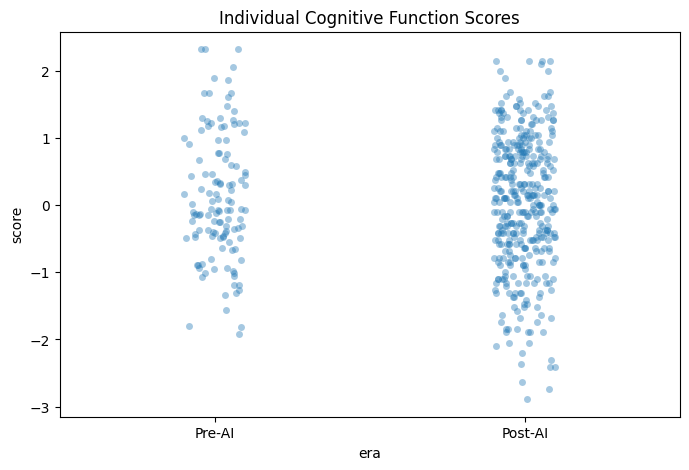

In [33]:
sample_df = df.sample(500)

plt.figure(figsize=(8,5))

sns.stripplot(
    data=sample_df,
    x="era",
    y="score",
    alpha=0.4
)

plt.title("Individual Cognitive Function Scores")
plt.show()

## QQ Plot: Assessing Normality of Pre-AI and Post-AI Cognitive Function Scores

This QQ plot compares the distribution of cognitive-function scores to a theoretical normal distribution. Most points closely follow the reference line, suggesting that the data are approximately normally distributed, with only minor deviations in the tails.

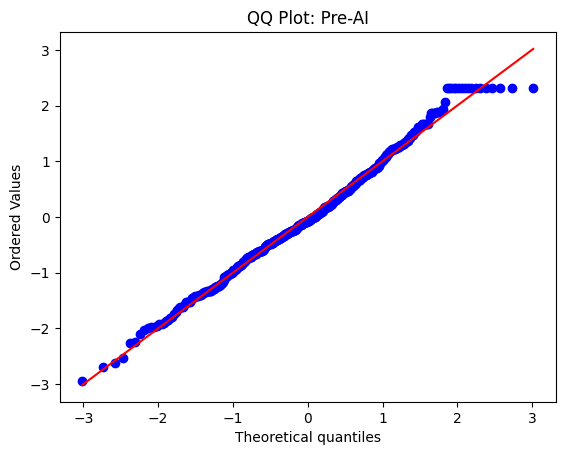

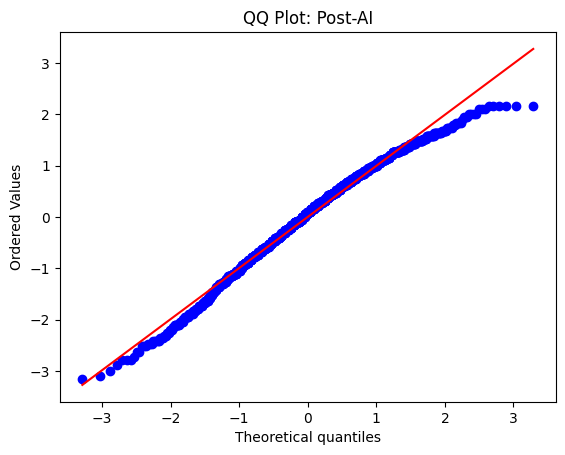

In [34]:
from scipy import stats

stats.probplot(pre_z, dist="norm", plot=plt)
plt.title("QQ Plot: Pre-AI")
plt.show()

stats.probplot(post_z, dist="norm", plot=plt)
plt.title("QQ Plot: Post-AI")
plt.show()



## Change in Mean Cognitive Function Scores Between Pre-AI and Post-AI Cohorts

This visualization compares the average standardized cognitive-function scores of students surveyed before and after the widespread adoption of generative AI. The graph shows a slight increase in the mean score for the Post-AI cohort; however, because both groups were standardized using z-scores, the difference appears very small and should be interpreted alongside the statistical tests and other visualizations.

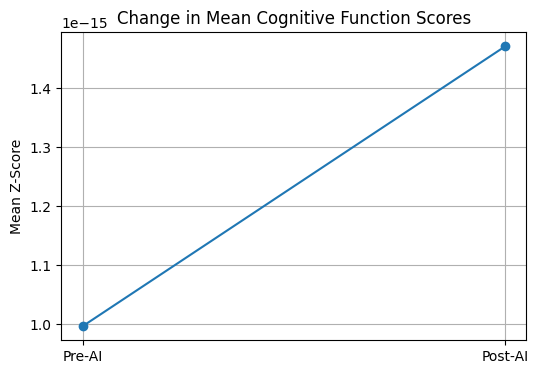

In [29]:
means = [pre_z.mean(), post_z.mean()]

plt.figure(figsize=(6,4))
plt.plot(["Pre-AI","Post-AI"], means, marker="o")
plt.ylabel("Mean Z-Score")
plt.title("Change in Mean Cognitive Function Scores")
plt.grid(True)

plt.show()


# Conclusion & Discussion

Based on the findings of the data analysis, we did not find a statistically significant difference in standardized cognitive-function scores between college students surveyed before and after the widespread adoption of generative AI. Although the post-AI cohort showed a slight higher median standardized score, the difference was not statistically significant according to the Mann-Whiney U test (p=0.314)
These findings do not support our original hypothesis that students surveyed after the widespread adoption of generative AI would report lower cognitive-function scores. While previous research has suggested that AI-assisted task completion may reduce cognitive engagement and increase cognitive offloading, our results indicate that such effects may not be reflected in broader self-reported cognitive-function measures at the population level. Overall, the results suggest that cognitive-function measures were largely similar across the two cohorts.

**Limitations**

Regardless of our findings, it is hard to conclude that the widespread use of AI directly influences cognitive functioning. Because neither dataset measured individual AI usage, we cannot attribute any observed similarities or differences to generative AI itself. Furthermore, correlation does not imply causation, and many factors other than AI may contribute to cognitive-function measures.
A major limitation of this study is that the two datasets were collected from different populations and used different survey instruments. Our datasets have way too many variables, different countries, languages, schooling systems, academic norms, etc… Additionally, while both datasets measured aspects of cognitive functioning, they did not assess identical constructs. Our project assumes that the popularization of AI is prevalent among college students. These differences introduce potential confounding variables that make direct comparisons challenging. Many societal and educational changes occurred between 2018 and 2025, making it difficult to isolate the potential influence of generative AI from other factors.


**Future direction**

There are still ongoing debates about whether generative AI has a positive correlation with reduced executive function. Some studies suggest that if used correctly, AI can lighten workloads and act as an educator. To better understand these effects, future studies could examine the context in which AI is used, rather than only focusing on cognitive tests. One type of study that would improve our findings is a direct AI usage measurement, combined with a longitudinal study, measuring students across a set number of years. This type of study could help determine whether frequent AI use leads to changes in executive function over time or whether certain ways of using AI actually support cognitive development and learning outcomes.
